# Proyecto Deep Learning - **SUDOKU**

### Importar librerías

In [ ]:
# Matrices y arrays
import numpy as np
import pandas as pd

# Visualizaciones y procesamiento de imágenes
import matplotlib.pyplot as plt
import cv2

# Manejo de rutas de archivos
from pathlib import Path

# Redes
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

### Definir rutas

In [ ]:
# Definir root
PROJECT_ROOT = Path("..")

DATA_DIR = PROJECT_ROOT / "data"
MODELS_DIR = PROJECT_ROOT / "models"
OUTPUTS_DIR = PROJECT_ROOT / "notebooks" / "outputs"
CELLS_DIR = OUTPUTS_DIR / "cells"

DIGIT_MODEL_PATH = MODELS_DIR / "../models/digit_cnn.keras"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

print("Ruta modelos:", MODELS_DIR)
print("Ruta celdas:", CELLS_DIR)
print("Existe carpeta de celdas:", CELLS_DIR.exists())

Ruta modelos: ..\models
Ruta celdas: ..\notebooks\outputs\cells
Existe carpeta de celdas: True


### 1. Cargar dataset de ***MNIST***

In [3]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print("x_train:", x_train.shape)
print("y_train:", y_train.shape)
print("x_test:", x_test.shape)
print("y_test:", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
x_train: (60000, 28, 28)
y_train: (60000,)
x_test: (10000, 28, 28)
y_test: (10000,)


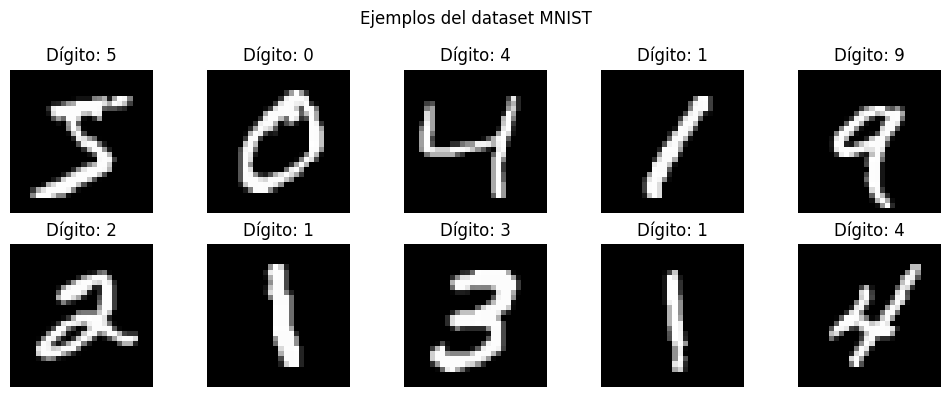

In [4]:
# Visualizar ejemplos de MNIST
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for ax, img, label in zip(axes.ravel(), x_train[:10], y_train[:10]):
    ax.imshow(img, cmap="gray")
    ax.set_title(f"Dígito: {label}")
    ax.axis("off")

plt.suptitle("Ejemplos del dataset MNIST")
plt.tight_layout()
plt.show()

### 2. Preparar datos para CNN

In [ ]:
# Normalizar imágenes a valores entre 0 y 1 (convertir píxeles de 0-255 a 0-1)
x_train_norm = x_train.astype("float32") / 255.0
x_test_norm = x_test.astype("float32") / 255.0

# Añadir canal de color: de (28, 28) a (28, 28, 1)
x_train_cnn = np.expand_dims(x_train_norm, axis=-1)
x_test_cnn = np.expand_dims(x_test_norm, axis=-1)

print("x_train_cnn:", x_train_cnn.shape)
print("x_test_cnn:", x_test_cnn.shape)

x_train_cnn: (60000, 28, 28, 1)
x_test_cnn: (10000, 28, 28, 1)


### 3. Entrenar modelo CNN multiclase

In [ ]:
# Definir modelo CNN multiclase
digit_model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),

    # Conv2D: detecta patrones visuales (líneas, curvas, bordes)
    layers.Conv2D(32, (3, 3), activation="relu"),
    # MaxPooling2D: reduce tamaño y conserva lo importante
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Flatten: convierte la imagen procesada en una lista de valores
    layers.Flatten(),

    # Dense: capas normales de la red neuronal
    layers.Dense(64, activation="relu"),

    # Dropout: ayuda a evitar sobreajuste
    layers.Dropout(0.3),

    # Dense(10, softmax): devuelve probabilidades para los dígitos 0 a 9
    layers.Dense(10, activation="softmax")
])

digit_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy", # etiquetas enteras (0, 1, 2, etc.)
    metrics=["accuracy"]
)

digit_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Entrenar el modelo
history = digit_model.fit(
    x_train_cnn,
    y_train,
    validation_split=0.2,
    epochs=5,
    batch_size=128,
    verbose=1
)

Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 15s 35ms/step - accuracy: 0.8871 - loss: 0.3715 - val_accuracy: 0.9722 - val_loss: 0.0925
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 13s 34ms/step - accuracy: 0.9662 - loss: 0.1134 - val_accuracy: 0.9833 - val_loss: 0.0595
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 13s 33ms/step - accuracy: 0.9749 - loss: 0.0848 - val_accuracy: 0.9858 - val_loss: 0.0493
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 21s 34ms/step - accuracy: 0.9795 - loss: 0.0668 - val_accuracy: 0.9869 - val_loss: 0.0473
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.9833 - loss: 0.0551 - val_accuracy: 0.9875 - val_loss: 0.0431


### 4. Evaluar el modelo

In [8]:
# Evaluar modelo en test
test_loss, test_accuracy = digit_model.evaluate(x_test_cnn, y_test, verbose=0)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")

Test loss: 0.0400
Test accuracy: 0.9875


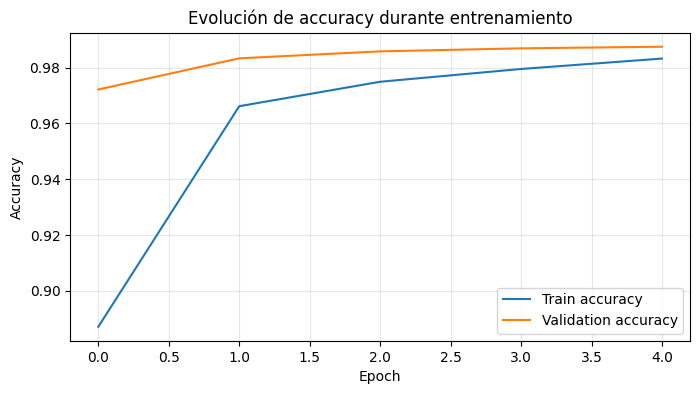

Gráfico guardado en: ..\notebooks\outputs\digit_model_training_history.png


In [10]:
# Visualizar evolución del entrenamiento

training_history_path = OUTPUTS_DIR / "digit_model_training_history.png"

plt.figure(figsize=(8, 4))

plt.plot(history.history["accuracy"], label="Train accuracy")
plt.plot(history.history["val_accuracy"], label="Validation accuracy")

plt.title("Evolución de accuracy durante entrenamiento")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)

plt.savefig(training_history_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Gráfico guardado en: {training_history_path}")

### 5. Guardar modelo entrenado

In [11]:
# Guardar modelo entrenado
digit_model.save(DIGIT_MODEL_PATH)

print(f"Modelo guardado en: {DIGIT_MODEL_PATH}")

Modelo guardado en: ..\models\digit_cnn.keras


#### 5.1.1. Probar el modelo guardado

In [ ]:
# Cargar modelo guardado para comprobar
loaded_digit_model = keras.models.load_model(DIGIT_MODEL_PATH)

print("Modelo cargado correctamente")
loaded_digit_model.summary()

Modelo cargado correctamente


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 365,792 (1.40 MB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 243,862 (952.59 KB)

In [ ]:
# Probar modelo cargado con imágenes MNIST
sample_images = x_test_cnn[:10] # Toma 10 imágenes del conjunto de test
sample_labels = y_test[:10]

# El modelo devuelve probabilidades para 0-9
predictions = loaded_digit_model.predict(sample_images)

#np.argmax: selecciona el dígito con mayor probabilidad.
predicted_labels = np.argmax(predictions, axis=1)

print("Etiquetas reales:    ", sample_labels)
print("Predicciones modelo:", predicted_labels)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
Etiquetas reales:     [7 2 1 0 4 1 4 9 5 9]
Predicciones modelo: [7 2 1 0 4 1 4 9 5 9]


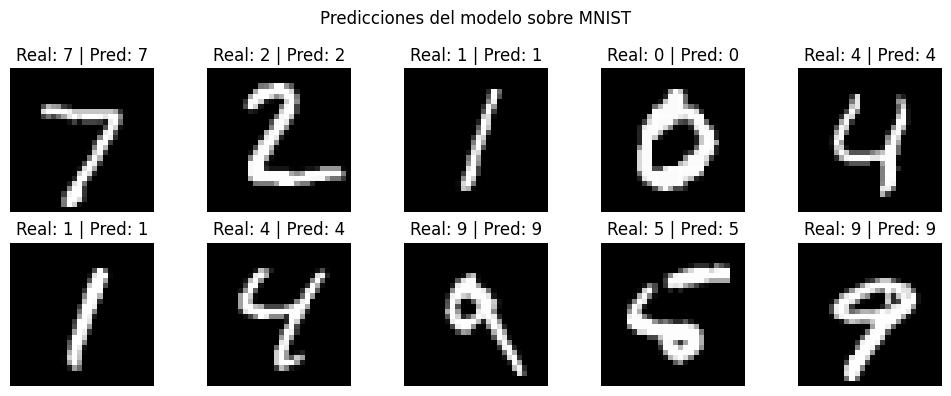

In [14]:
# Visualizar predicciones sobre MNIST
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for ax, img, true_label, pred_label in zip(
    axes.ravel(),
    sample_images,
    sample_labels,
    predicted_labels
):
    ax.imshow(img.squeeze(), cmap="gray")
    ax.set_title(f"Real: {true_label} | Pred: {pred_label}")
    ax.axis("off")

plt.suptitle("Predicciones del modelo sobre MNIST")
plt.tight_layout()
plt.show()

### 6. Cargar celdas del Sudoku

Probar el modelo con las celdas reales del Sudoku del jupyter ``01_yolo_detection``

In [ ]:
# Función para cargar las del Sudoku extraídas
def load_sudoku_cells(cells_dir):
    cells = [[None for _ in range(9)] for _ in range(9)]

    for row in range(9):
        for col in range(9):
            cell_path = cells_dir / f"cell_{row}_{col}.png"

            cell = cv2.imread(str(cell_path))

            if cell is None:
                raise FileNotFoundError(f"No se pudo cargar la celda: {cell_path}")

            cells[row][col] = cell

    return cells


cells = load_sudoku_cells(CELLS_DIR)

print("Celdas cargadas correctamente")
print("Ejemplo celda [0][1]:", cells[0][1].shape)

Celdas cargadas correctamente
Ejemplo celda [0][1]: (50, 50, 3)


In [16]:
# Reusar funciones de preprocesamiento reutilizadas del notebook 01
def crop_cell_margin(cell, margin=5):
    h, w = cell.shape[:2]
    return cell[margin:h-margin, margin:w-margin]

def preprocess_cell_for_digit(cell, margin=10):
    cell_crop = crop_cell_margin(cell, margin=margin)

    gray = cv2.cvtColor(cell_crop, cv2.COLOR_BGR2GRAY)

    blurred = cv2.GaussianBlur(gray, (3, 3), 0)

    thresh = cv2.adaptiveThreshold(
        blurred,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        11,
        2
    )

    return thresh

def is_empty_cell(processed_cell, threshold=65):
    white_pixels = cv2.countNonZero(processed_cell)
    return white_pixels < threshold

def extract_digit_region(processed_cell):
    coords = cv2.findNonZero(processed_cell)

    if coords is None:
        return None

    x, y, w, h = cv2.boundingRect(coords)

    digit = processed_cell[y:y+h, x:x+w]

    return digit

def keep_digit_component(processed_cell, min_area=15):
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(
        processed_cell,
        connectivity=8
    )

    cleaned = np.zeros_like(processed_cell)

    components = []

    for label in range(1, num_labels):
        x, y, w, h, area = stats[label]

        if area < min_area:
            continue

        is_thin_vertical_line = w <= 3 and h > 10
        is_thin_horizontal_line = h <= 3 and w > 10

        if is_thin_vertical_line or is_thin_horizontal_line:
            continue

        components.append((label, area))

    if len(components) == 0:
        return cleaned

    best_label = max(components, key=lambda item: item[1])[0]
    cleaned[labels == best_label] = 255

    return cleaned

def prepare_digit_for_mnist(processed_cell, output_size=28, digit_size=20):
    cleaned_cell = keep_digit_component(processed_cell)

    digit = extract_digit_region(cleaned_cell)

    if digit is None:
        return np.zeros((output_size, output_size), dtype=np.float32)

    h, w = digit.shape

    if h == 0 or w == 0:
        return np.zeros((output_size, output_size), dtype=np.float32)

    scale = digit_size / max(h, w)
    new_w = int(w * scale)
    new_h = int(h * scale)

    digit_resized = cv2.resize(
        digit,
        (new_w, new_h),
        interpolation=cv2.INTER_AREA
    )

    canvas = np.zeros((output_size, output_size), dtype=np.uint8)

    x_offset = (output_size - new_w) // 2
    y_offset = (output_size - new_h) // 2

    canvas[y_offset:y_offset+new_h, x_offset:x_offset+new_w] = digit_resized

    canvas = canvas.astype("float32") / 255.0

    return canvas

### 7. Preparar celdas para la predicción

In [17]:
# Preparar celdas reales para predicción

EMPTY_THRESHOLD = 65

mnist_cells = [[None for _ in range(9)] for _ in range(9)]
occupancy_matrix = np.zeros((9, 9), dtype=int)

for row in range(9):
    for col in range(9):
        processed = preprocess_cell_for_digit(cells[row][col], margin=10)

        if is_empty_cell(processed, threshold=EMPTY_THRESHOLD):
            mnist_cells[row][col] = None
            occupancy_matrix[row, col] = 0
        else:
            mnist_cells[row][col] = prepare_digit_for_mnist(processed)
            occupancy_matrix[row, col] = 1

occupancy_matrix

array([[0, 1, 0, 0, 0, 1, 1, 0, 0],
       [1, 0, 0, 1, 1, 1, 0, 0, 1],
       [1, 1, 0, 0, 0, 1, 0, 1, 1],
       [0, 0, 1, 1, 0, 0, 0, 1, 0],
       [1, 1, 0, 0, 0, 0, 0, 1, 1],
       [0, 1, 0, 0, 0, 1, 1, 0, 0],
       [1, 1, 0, 1, 0, 0, 0, 1, 1],
       [1, 0, 0, 1, 1, 1, 0, 0, 1],
       [0, 0, 1, 1, 0, 0, 0, 1, 0]])

#### 7.1. Visualizar celdas listas para predicción

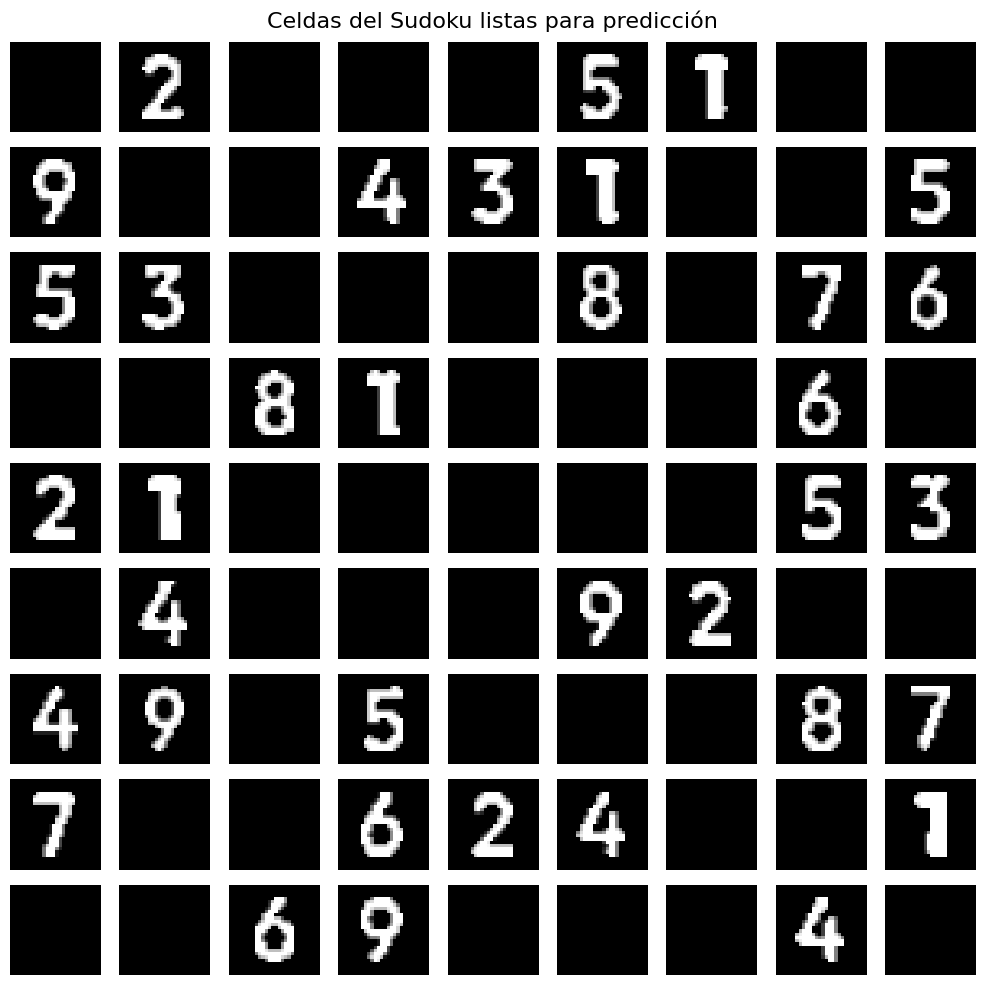

Visualización guardada en: ..\notebooks\outputs\sudoku_cells_ready_for_prediction.png


In [19]:
# Visualizar celdas listas para predicción
sudoku_cells_prediction_path = OUTPUTS_DIR / "sudoku_cells_ready_for_prediction.png"

fig, axes = plt.subplots(9, 9, figsize=(10, 10))

for row in range(9):
    for col in range(9):
        ax = axes[row, col]

        if mnist_cells[row][col] is None:
            ax.imshow(np.zeros((28, 28)), cmap="gray")
        else:
            ax.imshow(mnist_cells[row][col], cmap="gray")

        ax.axis("off")

plt.suptitle("Celdas del Sudoku listas para predicción", fontsize=16)
plt.tight_layout()

plt.savefig(sudoku_cells_prediction_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Visualización guardada en: {sudoku_cells_prediction_path}")

### 8. Predecir dígitos del tablero

In [20]:
# Predecir dígitos del tablero
predicted_grid = np.zeros((9, 9), dtype=int)
confidence_grid = np.zeros((9, 9), dtype=float)

for row in range(9):
    for col in range(9):

        if mnist_cells[row][col] is None:
            predicted_grid[row, col] = 0
            confidence_grid[row, col] = 0.0

        else:
            # Modelo espera forma: (n_imágenes, 28, 28, 1)
            image = mnist_cells[row][col].reshape(1, 28, 28, 1)

            probabilities = loaded_digit_model.predict(image, verbose=0)[0]

            predicted_digit = np.argmax(probabilities)
            confidence = np.max(probabilities)

            predicted_grid[row, col] = predicted_digit
            confidence_grid[row, col] = confidence

print("Matriz predicha:")
print(predicted_grid)

print("\nConfianza por celda:")
print(np.round(confidence_grid, 3))

Matriz predicha:
[[0 2 0 0 0 5 1 0 0]
 [9 0 0 4 3 1 0 0 5]
 [5 3 0 0 0 8 0 7 6]
 [0 0 8 1 0 0 0 6 0]
 [2 3 0 0 0 0 0 5 3]
 [0 4 0 0 0 9 2 0 0]
 [4 9 0 5 0 0 0 8 7]
 [7 0 0 6 2 4 0 0 7]
 [0 0 6 9 0 0 0 4 0]]

Confianza por celda:
[[0.    0.997 0.    0.    0.    1.    0.586 0.    0.   ]
 [0.864 0.    0.    0.998 1.    0.728 0.    0.    1.   ]
 [1.    1.    0.    0.    0.    0.948 0.    0.835 0.983]
 [0.    0.    0.998 0.722 0.    0.    0.    0.986 0.   ]
 [0.999 0.781 0.    0.    0.    0.    0.    1.    1.   ]
 [0.    0.998 0.    0.    0.    0.539 0.999 0.    0.   ]
 [0.999 0.944 0.    1.    0.    0.    0.    0.998 0.772]
 [0.852 0.    0.    0.993 0.999 0.999 0.    0.    0.615]
 [0.    0.    0.989 0.99  0.    0.    0.    0.996 0.   ]]


#### 8.1. Comparar con la matriz esperada

In [21]:
# Matriz esperada del Sudoku original
expected_grid = np.array([
    [0, 2, 0, 0, 0, 5, 1, 0, 0],
    [9, 0, 0, 4, 3, 1, 0, 0, 5],
    [5, 3, 0, 0, 0, 8, 0, 7, 6],
    [0, 0, 8, 1, 0, 0, 0, 6, 0],
    [2, 1, 0, 0, 0, 0, 0, 5, 3],
    [0, 4, 0, 0, 0, 9, 2, 0, 0],
    [4, 9, 0, 5, 0, 0, 0, 8, 7],
    [7, 0, 0, 6, 2, 4, 0, 0, 1],
    [0, 0, 6, 9, 0, 0, 0, 4, 0],
])

In [22]:
# Comparar predicción con matriz esperada
print("Matriz predicha:")
print(predicted_grid)

print("\nMatriz esperada:")
print(expected_grid)

print("\n¿Coinciden?")
print(np.array_equal(predicted_grid, expected_grid))

print("\nCeldas diferentes:")
differences = predicted_grid != expected_grid
print(np.argwhere(differences))

Matriz predicha:
[[0 2 0 0 0 5 1 0 0]
 [9 0 0 4 3 1 0 0 5]
 [5 3 0 0 0 8 0 7 6]
 [0 0 8 1 0 0 0 6 0]
 [2 3 0 0 0 0 0 5 3]
 [0 4 0 0 0 9 2 0 0]
 [4 9 0 5 0 0 0 8 7]
 [7 0 0 6 2 4 0 0 7]
 [0 0 6 9 0 0 0 4 0]]

Matriz esperada:
[[0 2 0 0 0 5 1 0 0]
 [9 0 0 4 3 1 0 0 5]
 [5 3 0 0 0 8 0 7 6]
 [0 0 8 1 0 0 0 6 0]
 [2 1 0 0 0 0 0 5 3]
 [0 4 0 0 0 9 2 0 0]
 [4 9 0 5 0 0 0 8 7]
 [7 0 0 6 2 4 0 0 1]
 [0 0 6 9 0 0 0 4 0]]

¿Coinciden?
False

Celdas diferentes:
[[4 1]
 [7 8]]


Errores detectados:

- Fila 5, columna 2: esperaba 1, predijo 3.
- Fila 8, columna 9: esperaba 1, predijo 7.

Ambos errores corresponden a dígitos visualmente similares. Por este motivo, la aplicación final incluirá una revisión manual de la matriz antes de resolver el Sudoku.

### Conclusión del reconocimiento de dígitos

El modelo CNN entrenado con ***MNIST*** consigue reconocer la mayoría de los dígitos del tablero correctamente.

En esta imagen de prueba, la matriz predicha coincide casi por completo con la matriz esperada, con errores puntuales en dígitos visualmente similares. Por este motivo, en la aplicación final se incluirá una etapa de revisión manual de la matriz antes de resolver el Sudoku.

### 9. Construir matriz ``9x9``

In [23]:
# Construir matriz 9x9 del Sudoku
sudoku_matrix = predicted_grid.copy()

print("Matriz 9x9 construida a partir de la imagen:")
print(sudoku_matrix)

print("\nForma de la matriz:", sudoku_matrix.shape)

Matriz 9x9 construida a partir de la imagen:
[[0 2 0 0 0 5 1 0 0]
 [9 0 0 4 3 1 0 0 5]
 [5 3 0 0 0 8 0 7 6]
 [0 0 8 1 0 0 0 6 0]
 [2 3 0 0 0 0 0 5 3]
 [0 4 0 0 0 9 2 0 0]
 [4 9 0 5 0 0 0 8 7]
 [7 0 0 6 2 4 0 0 7]
 [0 0 6 9 0 0 0 4 0]]

Forma de la matriz: (9, 9)


In [24]:
sudoku_matrix_corrected = sudoku_matrix.copy()

sudoku_matrix_corrected[4, 1] = 1
sudoku_matrix_corrected[7, 8] = 1

print("Matriz corregida manualmente:")
print(sudoku_matrix_corrected)

Matriz corregida manualmente:
[[0 2 0 0 0 5 1 0 0]
 [9 0 0 4 3 1 0 0 5]
 [5 3 0 0 0 8 0 7 6]
 [0 0 8 1 0 0 0 6 0]
 [2 1 0 0 0 0 0 5 3]
 [0 4 0 0 0 9 2 0 0]
 [4 9 0 5 0 0 0 8 7]
 [7 0 0 6 2 4 0 0 1]
 [0 0 6 9 0 0 0 4 0]]


#### 9.1. Guardar la matriz corregida

In [25]:
SUDOKU_MATRIX_PATH = OUTPUTS_DIR / "sudoku_matrix_corrected.npy"

np.save(SUDOKU_MATRIX_PATH, sudoku_matrix_corrected)

print(f"Matriz corregida guardada en: {SUDOKU_MATRIX_PATH}")

Matriz corregida guardada en: ..\notebooks\outputs\sudoku_matrix_corrected.npy
